In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT    = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
RUN_7B  = os.path.join(ROOT, 'results', 'training')               # Llama-2-7B (local)
RUN_13B = os.path.join(ROOT, 'results', 'training_cluster_good')  # Llama-2-13B (cluster)
OUT_DIR = os.path.join(ROOT, 'results', 'visualizations')
os.makedirs(OUT_DIR, exist_ok=True)

# ── Style ──────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.1)
COLORS = {'7b': '#2196F3', '13b': '#FF5722'}
LABELS = {'7b': 'Llama-2-7B', '13b': 'Llama-2-13B'}
MODELS = [('7b', LABELS['7b']), ('13b', LABELS['13b'])]

print("Environment ready.")

Environment ready.


In [2]:
# ── Load inference outputs ─────────────────────────────────────────────────────
EPOCH = 10

def load_7b(split):
    """7B: {split}_output_inference_LORA_10_epochs_Llama-2-7b-chat-hf.csv"""
    fname = f"{split}_output_inference_LORA_{EPOCH}_epochs_Llama-2-7b-chat-hf.csv"
    df = pd.read_csv(os.path.join(RUN_7B, fname))
    df.columns = ['preds', 'actuals']
    df['residuals'] = df['actuals'] - df['preds']
    return df

def load_13b(split):
    """13B: {split}_output_sctt_results_LORA_10_epochs_Llama-2-13b-chat-hf.csv
       heldout uses 'heldoutprompt' prefix."""
    prefix = 'heldoutprompt' if split == 'heldout' else split
    fname = f"{prefix}_output_sctt_results_LORA_{EPOCH}_epochs_Llama-2-13b-chat-hf.csv"
    df = pd.read_csv(os.path.join(RUN_13B, fname))
    df.columns = ['preds', 'actuals']
    df['residuals'] = df['actuals'] - df['preds']
    return df

LOADERS = {'7b': load_7b, '13b': load_13b}

data = {}
for split in ['train', 'validation', 'test', 'heldout']:
    for model, loader in LOADERS.items():
        try:
            data[f"{model}_{split}"] = loader(split)
            print(f"  Loaded {model:3s} | {split:12s} | n={len(data[f'{model}_{split}']):,}")
        except FileNotFoundError:
            print(f"  MISSING: {model} | {split}")

print("\nAll available datasets loaded.")

  Loaded 7b  | train        | n=11,967
  MISSING: 13b | train
  Loaded 7b  | validation   | n=1,710
  Loaded 13b | validation   | n=1,710
  Loaded 7b  | test         | n=3,420
  Loaded 13b | test         | n=3,420
  Loaded 7b  | heldout      | n=1,062
  Loaded 13b | heldout      | n=1,062

All available datasets loaded.


In [3]:
# ── Compute metrics ────────────────────────────────────────────────────────────
def compute_metrics(df):
    r, p = stats.pearsonr(df['actuals'], df['preds'])
    mae  = mean_absolute_error(df['actuals'], df['preds'])
    rmse = np.sqrt(mean_squared_error(df['actuals'], df['preds']))
    r2   = r2_score(df['actuals'], df['preds'])
    return {'Pearson r': r, 'p-value': p, 'MAE': mae, 'RMSE': rmse, 'R²': r2, 'n': len(df)}

metrics = {key: compute_metrics(df) for key, df in data.items()}

rows = []
for key, m in metrics.items():
    model, split = key.split('_', 1)
    rows.append({'Model': LABELS[model], 'Split': split, **m})
metrics_df = pd.DataFrame(rows).set_index(['Model', 'Split'])
print(metrics_df[['Pearson r', 'MAE', 'RMSE', 'R²', 'n']].round(2).to_string())

                        Pearson r   MAE  RMSE    R²      n
Model       Split                                         
Llama-2-7B  train            0.96  0.03  0.04  0.91  11967
            validation       0.72  0.08  0.10  0.52   1710
Llama-2-13B validation       0.71  0.08  0.10  0.49   1710
Llama-2-7B  test             0.74  0.08  0.10  0.55   3420
Llama-2-13B test             0.73  0.08  0.10  0.51   3420
Llama-2-7B  heldout          0.49  0.11  0.14  0.23   1062
Llama-2-13B heldout          0.46  0.12  0.15  0.02   1062


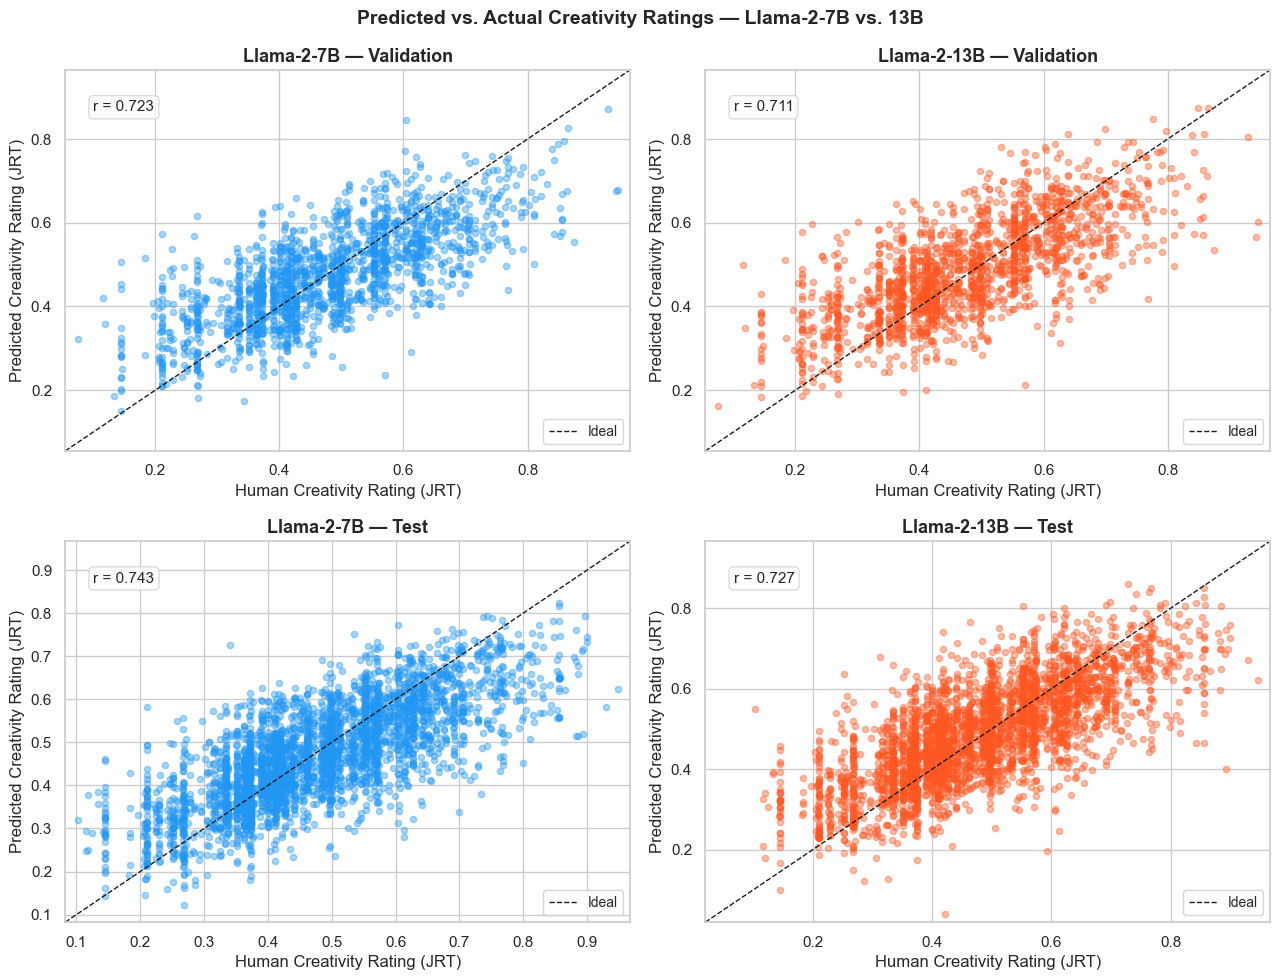

In [4]:
# ── Fig 1: Predicted vs Actual — Val & Test ───────────────────────────────────
plot_splits = ['validation', 'test']
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for col, (model, label) in enumerate(MODELS):
    for row, split in enumerate(plot_splits):
        ax  = axes[row, col]
        key = f"{model}_{split}"
        if key not in data:
            ax.set_visible(False)
            continue
        df = data[key]
        m  = metrics[key]

        ax.scatter(df['actuals'], df['preds'],
                   alpha=0.4, s=20,
                   color=COLORS[model], rasterized=True)

        lims = [min(df['actuals'].min(), df['preds'].min()) - 0.02,
                max(df['actuals'].max(), df['preds'].max()) + 0.02]
        ax.plot(lims, lims, 'k--', lw=1, label='Ideal')
        ax.set_xlim(lims); ax.set_ylim(lims)

        ax.set_xlabel('Human Creativity Rating (JRT)', fontsize=12)
        ax.set_ylabel('Predicted Creativity Rating (JRT)', fontsize=12)
        ax.set_title(f"{label} — {split.capitalize()}", fontsize=13, fontweight='bold')
        ax.tick_params(labelsize=11)

        # r annotation as inset text box instead of cluttering the title
        ax.text(0.05, 0.92, f"r = {m['Pearson r']:.3f}",
                transform=ax.transAxes, fontsize=11,
                verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor='lightgray', alpha=0.8))
        ax.legend(fontsize=10)

fig.suptitle('Predicted vs. Actual Creativity Ratings — Llama-2-7B vs. 13B',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'regression_scatter_pred_vs_actual.png'),
            dpi=300, bbox_inches='tight')
plt.show()

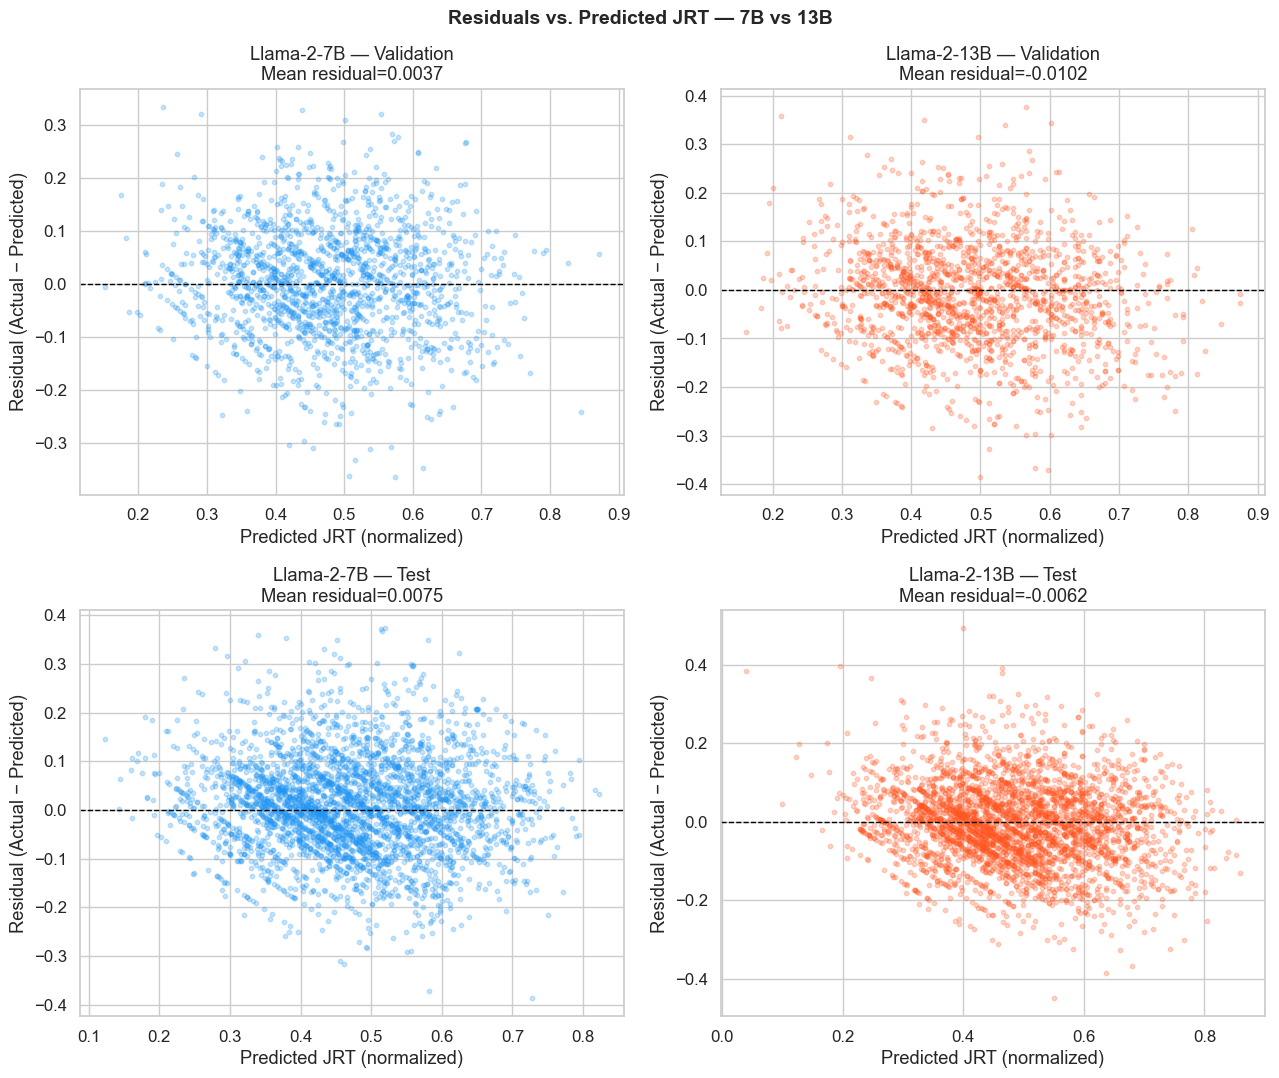

Saved → results/visualizations/residuals_vs_predicted.png


In [5]:
# ── Fig 2: Residuals vs Predicted ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 11))

for col, (model, label) in enumerate(MODELS):
    for row, split in enumerate(plot_splits):
        ax  = axes[row, col]
        key = f"{model}_{split}"
        if key not in data:
            ax.set_visible(False)
            continue
        df = data[key]
        ax.scatter(df['preds'], df['residuals'], alpha=0.25, s=10,
                   color=COLORS[model], rasterized=True)
        ax.axhline(0, color='black', linestyle='--', lw=1)
        ax.set_xlabel('Predicted JRT (normalized)')
        ax.set_ylabel('Residual (Actual − Predicted)')
        ax.set_title(f"{label} — {split.capitalize()}\nMean residual={df['residuals'].mean():.4f}")

fig.suptitle('Residuals vs. Predicted JRT — 7B vs 13B', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'residuals_vs_predicted.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/visualizations/residuals_vs_predicted.png")

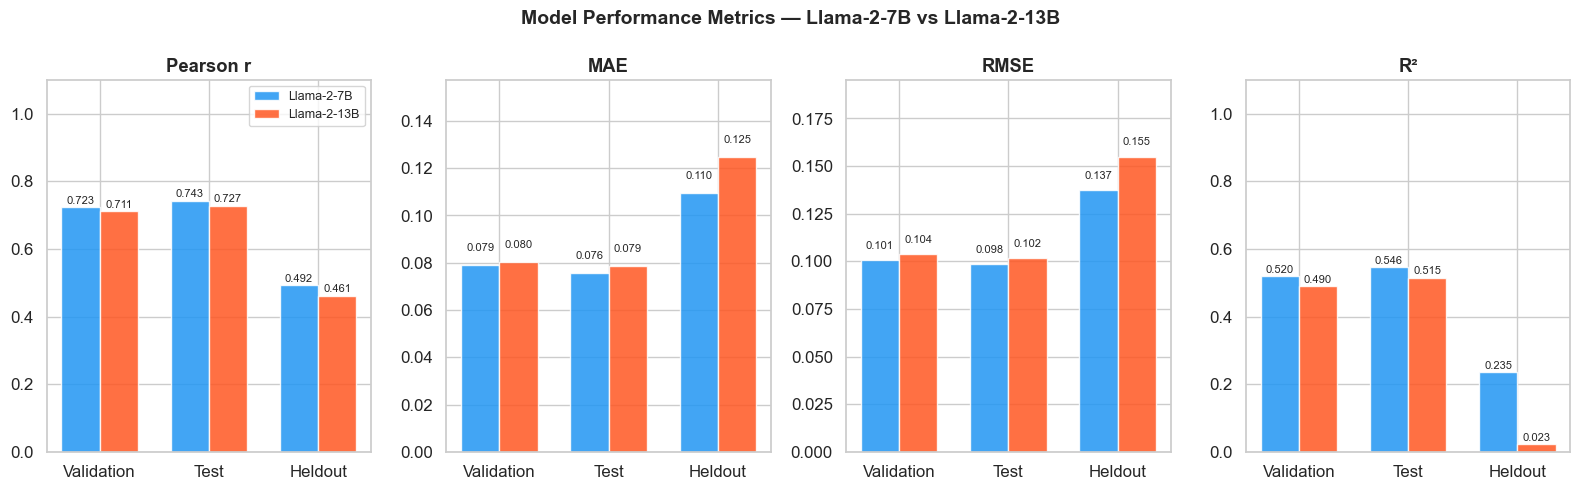

Saved → results/visualizations/metrics_comparison.png


In [6]:
# ── Fig 3: Metrics Comparison Bar Chart ───────────────────────────────────────
metric_names = ['Pearson r', 'MAE', 'RMSE', 'R²']
eval_splits  = ['validation', 'test', 'heldout']

fig, axes = plt.subplots(1, len(metric_names), figsize=(16, 5))
x     = np.arange(len(eval_splits))
width = 0.35

for ax, metric in zip(axes, metric_names):
    for i, (model, label) in enumerate(MODELS):
        vals = [metrics[f"{model}_{s}"][metric] if f"{model}_{s}" in metrics else np.nan
                for s in eval_splits]
        offset = (i - 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=label,
                      color=COLORS[model], alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                        f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(metric, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([s.capitalize() for s in eval_splits])
    if metric in ['Pearson r', 'R²']:
        ax.set_ylim(0, 1.1)
    else:
        ax.set_ylim(0, max(0.05, ax.get_ylim()[1] * 1.2))

axes[0].legend(loc='upper right', fontsize=9)
fig.suptitle('Model Performance Metrics — Llama-2-7B vs Llama-2-13B', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'metrics_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/visualizations/metrics_comparison.png")

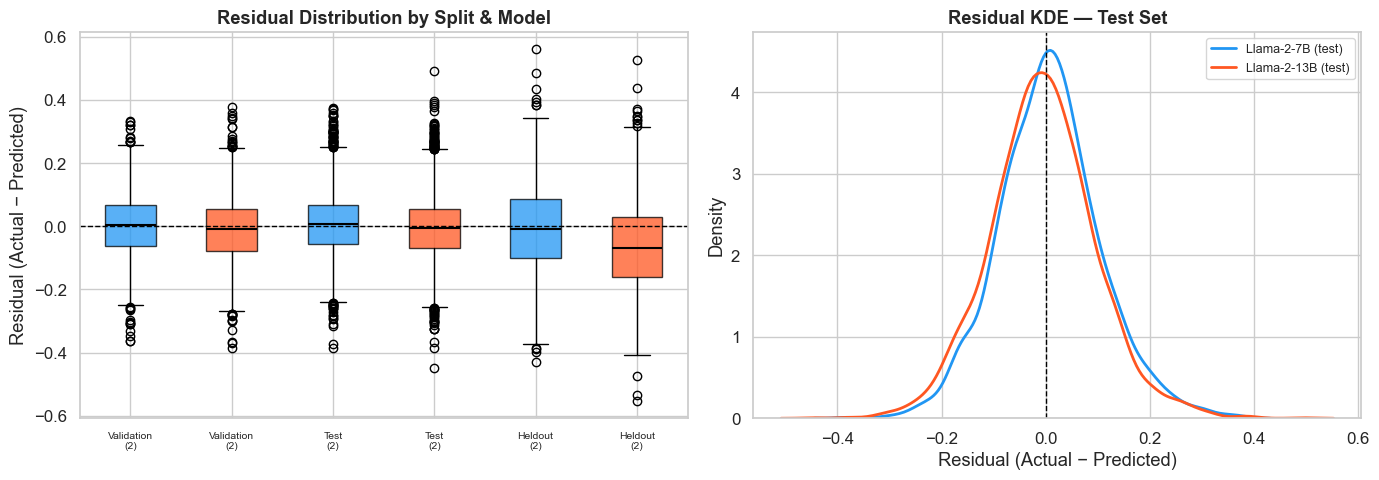

Saved → results/visualizations/residual_distributions.png


In [7]:
# ── Fig 4: Residual Distribution — Box + KDE ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot — all eval splits, both models
box_data, box_labels, box_colors = [], [], []
for split in eval_splits:
    for model, label in MODELS:
        key = f"{model}_{split}"
        if key in data:
            box_data.append(data[key]['residuals'].values)
            box_labels.append(f"{split.capitalize()}\n({label.split('-')[1]})")
            box_colors.append(COLORS[model])

bp = axes[0].boxplot(box_data, patch_artist=True, notch=False,
                     medianprops=dict(color='black', lw=1.5))
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[0].set_xticklabels(box_labels, fontsize=7.5)
axes[0].axhline(0, color='black', linestyle='--', lw=1)
axes[0].set_ylabel('Residual (Actual − Predicted)')
axes[0].set_title('Residual Distribution by Split & Model', fontweight='bold')

# KDE — test split, both models
for model, label in MODELS:
    key = f"{model}_test"
    if key in data:
        sns.kdeplot(data[key]['residuals'], ax=axes[1],
                    label=f"{label} (test)", color=COLORS[model], linewidth=2)
axes[1].axvline(0, color='black', linestyle='--', lw=1)
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Density')
axes[1].set_title('Residual KDE — Test Set', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'residual_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/visualizations/residual_distributions.png")

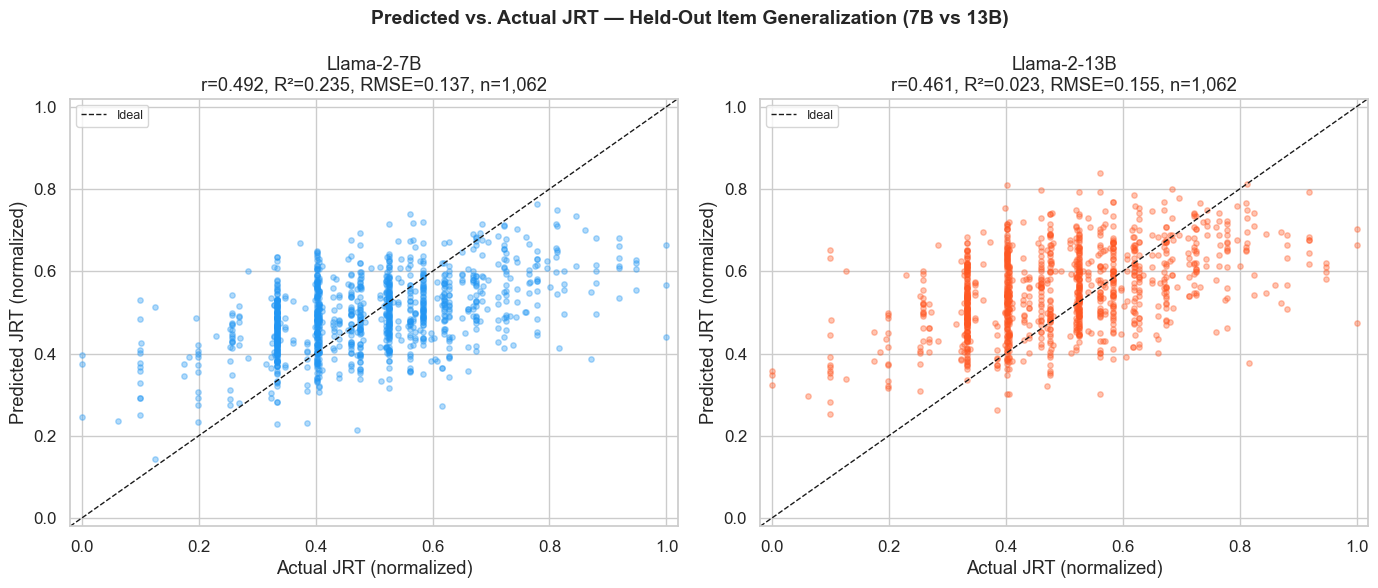

Saved → results/visualizations/scatter_heldout_generalization.png


In [8]:
# ── Fig 5: Held-Out Generalization Scatter ────────────────────────────────────
heldout_models = [(m, l) for m, l in MODELS if f"{m}_heldout" in data]
fig, axes = plt.subplots(1, len(heldout_models), figsize=(7 * len(heldout_models), 6))
if len(heldout_models) == 1:
    axes = [axes]

for ax, (model, label) in zip(axes, heldout_models):
    key = f"{model}_heldout"
    df  = data[key]
    m   = metrics[key]
    ax.scatter(df['actuals'], df['preds'], alpha=0.35, s=15, color=COLORS[model], rasterized=True)
    lims = [min(df['actuals'].min(), df['preds'].min()) - 0.02,
            max(df['actuals'].max(), df['preds'].max()) + 0.02]
    ax.plot(lims, lims, 'k--', lw=1, label='Ideal')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual JRT (normalized)')
    ax.set_ylabel('Predicted JRT (normalized)')
    ax.set_title(f"{label}\nr={m['Pearson r']:.3f}, R²={m['R²']:.3f}, RMSE={m['RMSE']:.3f}, n={m['n']:,}")
    ax.legend(fontsize=9)

fig.suptitle('Predicted vs. Actual JRT — Held-Out Item Generalization (7B vs 13B)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'scatter_heldout_generalization.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/visualizations/scatter_heldout_generalization.png")

In [9]:
# ── Load Phase 2 forward-pass predictions (greedy only) ───────────────────────
PHASE2_DIR   = os.path.join(ROOT, 'phase2_results')
PARQUET_FILE = 'all_forward_pass_predictions_20260221_061756_7b_regresion'

df_phase2 = pd.read_parquet(os.path.join(PHASE2_DIR, PARQUET_FILE))
df_greedy = df_phase2[df_phase2['forward_pass_type'] == 'greedy'].copy()

print(f"Total rows:  {len(df_phase2):,}  |  Greedy rows: {len(df_greedy):,}")
print(f"Columns: {df_greedy.columns.tolist()}")
df_greedy.head()


Total rows:  208,620  |  Greedy rows: 3,420
Columns: ['sample_id', 'item', 'prompt', 'response', 'label_true', 'n_generations', 'forward_pass_type', 'forward_pass_idx', 'sequence_text', 'sequence_score', 'sequence_log_prob', 'cluster_id', 'semantic_entropy', 'num_clusters', 'ci_lower', 'ci_upper', 'ci_width', 'error', 'needs_review']


,sample_id,item,prompt,response,label_true,n_generations,forward_pass_type,forward_pass_idx,sequence_text,sequence_score,sequence_log_prob,cluster_id,semantic_entropy,num_clusters,ci_lower,ci_upper,ci_width,error,needs_review
0,185-study_2-8722,planet,a new planet outside of our galaxy,how are conditions different than earth,0.497891,60,greedy,-1,how are conditions different than earth,0.513672,NaN,NaN,0.0,1,0.513672,0.513672,0.0,0.015781,False
61,94046-study_3-1017,communicate,a remote island with nonverbal communication,Where did they come up with the sounds to comm...,0.598035,60,greedy,-1,Where did they come up with the sounds to comm...,0.562988,NaN,NaN,0.0,1,0.562988,0.562988,0.0,0.035047,False
122,113-study_1-4319,sing,why students sing in hallways at a new school,everyone at your old school came from differen...,0.748596,60,greedy,-1,everyone at your old school came from differen...,0.638672,NaN,NaN,0.0,1,0.638672,0.638672,0.0,0.109924,False
183,74-study_2-7050,jungle,a jungle containing no human life,how old is this island?,0.350929,60,greedy,-1,how old is this island?,0.525391,NaN,NaN,0.0,1,0.525391,0.525391,0.0,0.174462,False
244,92184-study_3-2595,sing,why students sing in hallways at a new school,This new school is more accepting of all peopl...,0.562727,60,greedy,-1,This new school is more accepting of all peopl...,0.624512,NaN,NaN,0.0,1,0.624512,0.624512,0.0,0.061785,False



  Llama-2-7B — Per-Item MAE vs n_train
       item      mae  n_train
      robot 0.064663      266
     jungle 0.065477     1474
      ocean 0.066190      804
      holes 0.066398      273
     flower 0.069203      251
       sing 0.070356      818
     planet 0.070550     1505
      humor 0.075248      785
   friendly 0.077538      844
       lake 0.077964      852
       dogs 0.083354      828
communicate 0.084175      804
      stars 0.086434      843
      birds 0.086793      805
       mind 0.091336      817
r = 0.109  p = 0.6983

  Llama-2-7B — Per-Bucket MAE vs n_train
label_bucket  n_train  n_pred      mae
     0.1–0.2      237      46 0.153090
     0.2–0.3      938     272 0.090086
     0.3–0.4     2251     700 0.066680
     0.4–0.5     3335     981 0.058158
     0.5–0.6     2548     667 0.067243
     0.6–0.7     1755     500 0.085377
     0.7–0.8      655     184 0.124631
     0.8–0.9      220      68 0.192006
     0.9–1.0       23       2 0.338228
r = -0.756  p = 0.0184


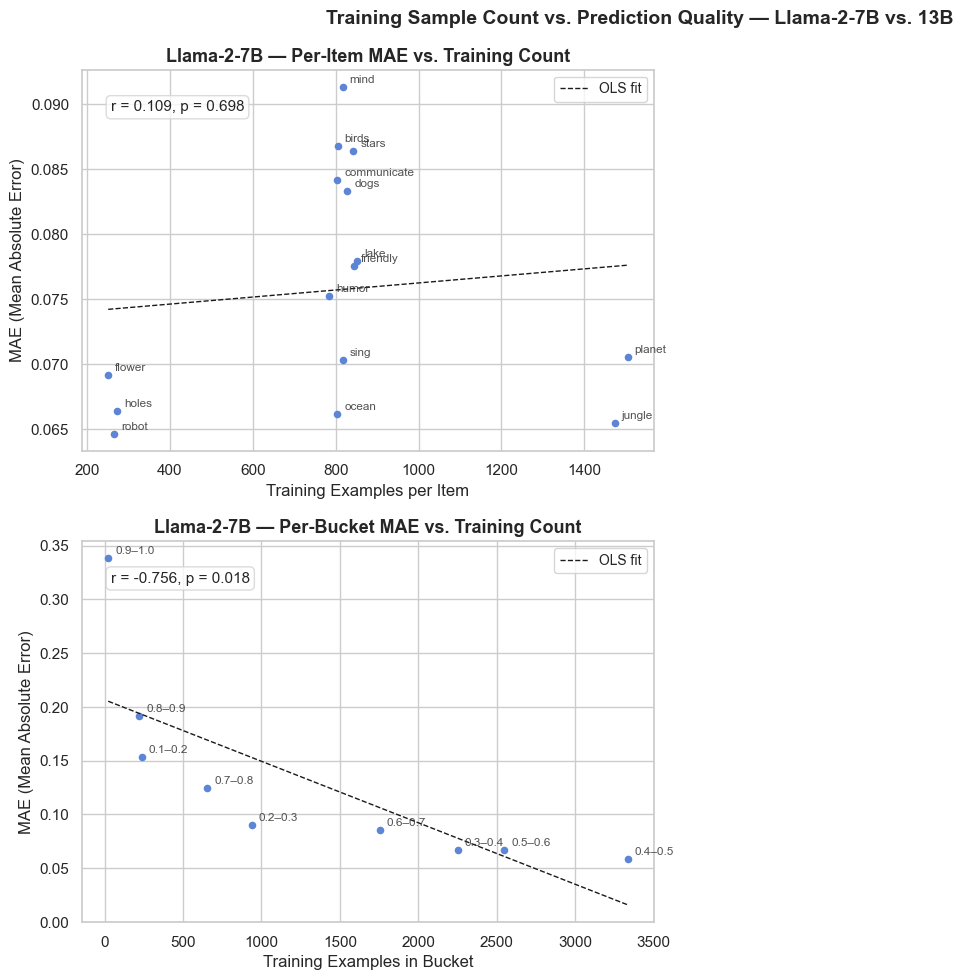


Saved → .\train_count_vs_quality.png


In [13]:

# ── Training Count vs Prediction Quality — 7B and 13B Stacked ────────────────
TRAIN_PATH = os.path.join(ROOT, 'data', 'processed', 'training_items_sctt.csv')
df_train_items = pd.read_csv(TRAIN_PATH)

# ── Shared bucket setup ───────────────────────────────────────────────────────
bins        = np.arange(0, 1.1, 0.1)
buck_labels = [f"{b:.1f}–{b+0.1:.1f}" for b in bins[:-1]]

df_train_items['label_bucket'] = pd.cut(df_train_items['label'], bins=bins,
                                         labels=buck_labels, include_lowest=True)
train_bucket_counts = (df_train_items.groupby('label_bucket', observed=True)
                                     .size().reset_index(name='n_train'))
item_train_counts = df_train_items.groupby('item').size().reset_index(name='n_train')


# ── Reusable plot function (one row) ─────────────────────────────────────────
def plot_train_vs_mae_row(df, axes_row, model_key, model_label):
    color = COLORS[model_key]

    # ── Panel A: Per-item n_train vs MAE ─────────────────────────────────────
    item_mae_rows = []
    for item, grp in df.groupby('item'):
        mae = (grp['sequence_score'] - grp['label_true']).abs().mean()
        item_mae_rows.append({'item': item, 'mae': mae})
    item_mae_df = pd.DataFrame(item_mae_rows)

    corr_df = item_mae_df.merge(item_train_counts, on='item', how='inner')
    r_item, p_item = stats.pearsonr(corr_df['n_train'], corr_df['mae'])
    print(f"\n{'='*55}")
    print(f"  {model_label} — Per-Item MAE vs n_train")
    print(f"{'='*55}")
    print(corr_df[['item', 'mae', 'n_train']].sort_values('mae').to_string(index=False))
    print(f"r = {r_item:.3f}  p = {p_item:.4f}")

    ax = axes_row[0]
    xs, ys = corr_df['n_train'], corr_df['mae']
    ax.scatter(xs, ys, s=20, color=color, rasterized=True)
    for _, row in corr_df.iterrows():
        ax.annotate(row['item'], (row['n_train'], row['mae']),
                    textcoords='offset points', xytext=(5, 3),
                    fontsize=8.5, alpha=0.85, color='#333333')
    m, b = np.polyfit(xs, ys, 1)
    x_line = np.linspace(xs.min(), xs.max(), 200)
    ax.plot(x_line, m * x_line + b, 'k--', lw=1, label='OLS fit')
    ax.set_xlabel('Training Examples per Item', fontsize=12)
    ax.set_ylabel('MAE (Mean Absolute Error)', fontsize=12)
    ax.set_title(f'{model_label} — Per-Item MAE vs. Training Count',
                 fontsize=13, fontweight='bold')
    ax.tick_params(labelsize=11)
    ax.text(0.05, 0.92, f"r = {r_item:.3f}, p = {p_item:.3f}",
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='lightgray', alpha=0.8))
    ax.legend(fontsize=10)

    # ── Panel B: Per-bucket n_train vs MAE ───────────────────────────────────
    df_tmp = df.copy()
    df_tmp['abs_error']    = (df_tmp['sequence_score'] - df_tmp['label_true']).abs()
    df_tmp['label_bucket'] = pd.cut(df_tmp['label_true'], bins=bins,
                                     labels=buck_labels, include_lowest=True)
    bucket_mae = (df_tmp.groupby('label_bucket', observed=True)
                        .agg(mae=('abs_error', 'mean'),
                             n_pred=('label_true', 'count'))
                        .reset_index())
    bucket_plot_df = bucket_mae.merge(train_bucket_counts, on='label_bucket', how='left')
    bucket_plot_df['n_train'] = bucket_plot_df['n_train'].fillna(0).astype(int)

    r_buck, p_buck = stats.pearsonr(bucket_plot_df['n_train'], bucket_plot_df['mae'])
    print(f"\n  {model_label} — Per-Bucket MAE vs n_train")
    print(bucket_plot_df[['label_bucket', 'n_train', 'n_pred', 'mae']].to_string(index=False))
    print(f"r = {r_buck:.3f}  p = {p_buck:.4f}")

    ax2 = axes_row[1]
    ax2.scatter(bucket_plot_df['n_train'], bucket_plot_df['mae'],
                s=20, color=color, rasterized=True)
    for _, row in bucket_plot_df.iterrows():
        ax2.annotate(row['label_bucket'], (row['n_train'], row['mae']),
                     textcoords='offset points', xytext=(5, 3),
                     fontsize=8.5, alpha=0.85, color='#333333')
    xb = bucket_plot_df['n_train']
    mb, bb = np.polyfit(xb, bucket_plot_df['mae'], 1)
    xl = np.linspace(xb.min(), xb.max(), 200)
    ax2.plot(xl, mb * xl + bb, 'k--', lw=1, label='OLS fit')
    ax2.set_xlabel('Training Examples in Bucket', fontsize=12)
    ax2.set_ylabel('MAE (Mean Absolute Error)', fontsize=12)
    ax2.set_title(f'{model_label} — Per-Bucket MAE vs. Training Count',
                  fontsize=13, fontweight='bold')
    ax2.tick_params(labelsize=11)
    ax2.text(0.05, 0.92, f"r = {r_buck:.3f}, p = {p_buck:.3f}",
             transform=ax2.transAxes, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                       edgecolor='lightgray', alpha=0.8))
    ax2.legend(fontsize=10)


# ── Build 2x2 figure: rows = panels, cols = models ───────────────────────────
# Row 0 = Per-Item MAE,  Row 1 = Per-Bucket MAE
# Col 0 = 7B,            Col 1 = 13B (left empty until data is available)
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Training Sample Count vs. Prediction Quality — Llama-2-7B vs. 13B',
             fontsize=14, fontweight='bold')

for col, (model, label) in enumerate(MODELS):
    if model == '7b':
        df = df_greedy
    else:
        try:
            df = df_greedy_13b
        except NameError:
            df = None

    if df is None:
        for ax in axes[:, col]:
            ax.set_visible(False)
        continue
    # Pass the two axes for this model's column as a row to the helper
    plot_train_vs_mae_row(df, [axes[0, col], axes[1, col]], model, label)

plt.tight_layout()
fname = os.path.join(OUT_DIR, 'train_count_vs_quality.png')
plt.savefig(fname, dpi=300, bbox_inches='tight')
plt.show()
print(f"\nSaved → {fname}")



  Llama-2-7B — Per-Bucket Error Summary
label_bucket   n      bias      mae
     0.1–0.2  46  0.152961 0.153090
     0.2–0.3 272  0.075508 0.090086
     0.3–0.4 700  0.040467 0.066680
     0.4–0.5 981  0.007925 0.058158
     0.5–0.6 667 -0.030390 0.067243
     0.6–0.7 500 -0.070633 0.085377
     0.7–0.8 184 -0.121738 0.124631
     0.8–0.9  68 -0.192006 0.192006
     0.9–1.0   2 -0.338228 0.338228


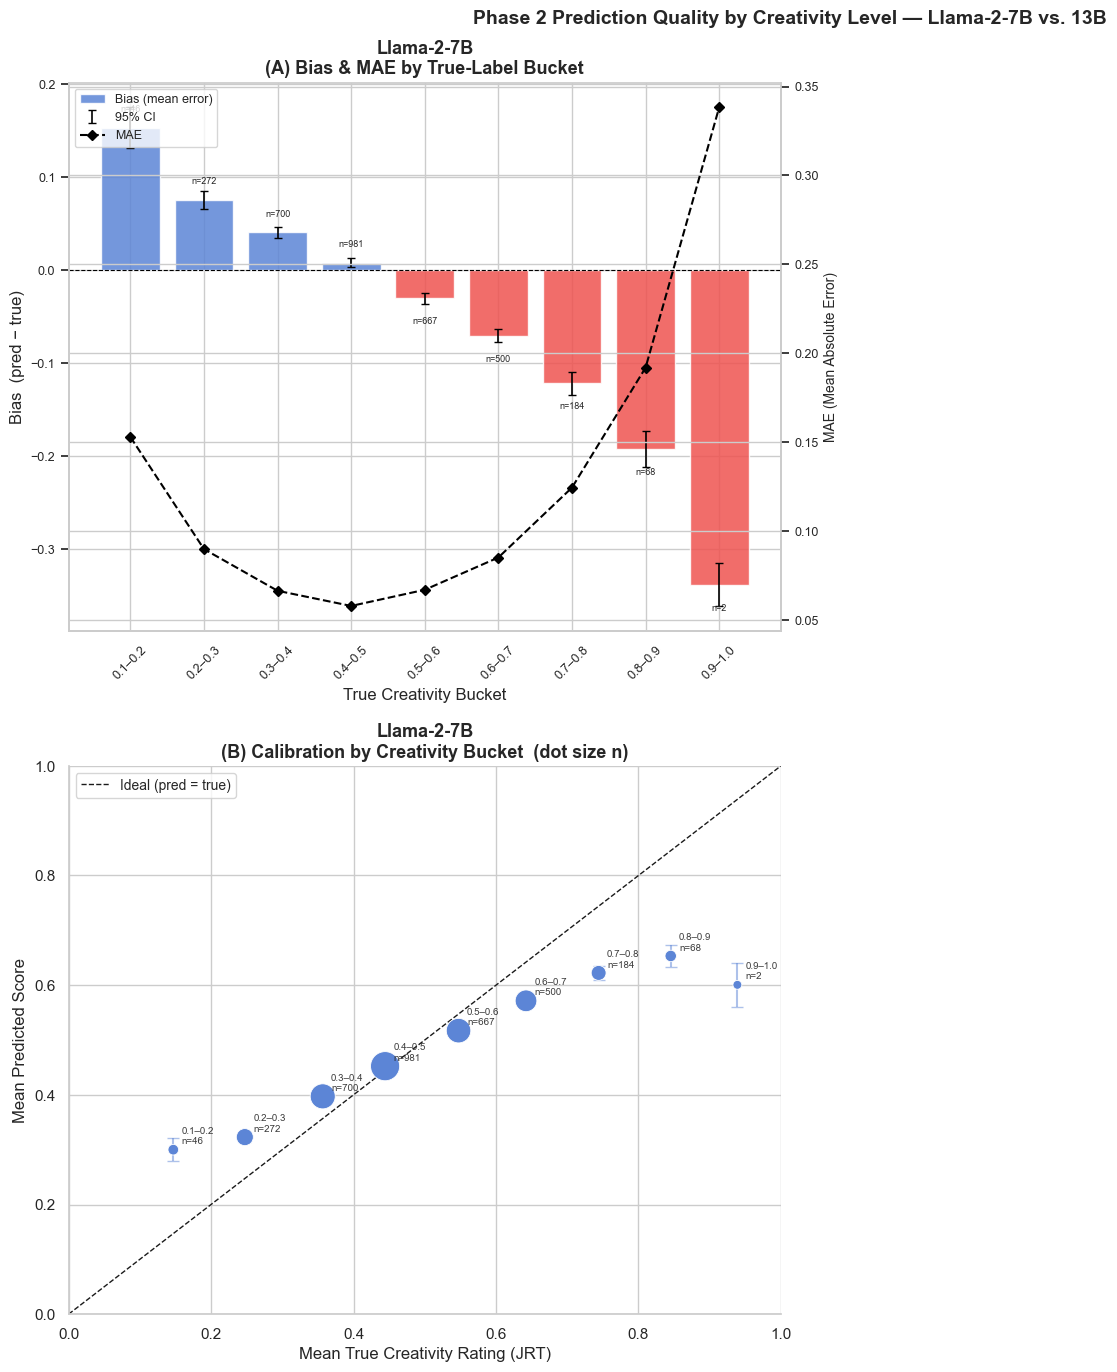


Saved → .\phase2_bias_calibration.png


In [16]:
def plot_phase2_corrected(df, axes_row, model_key, model_label):
    """
    Parameters
    ----------
    df          : DataFrame with columns 'item', 'label_true', 'sequence_score'
    axes_row    : list of 2 axes [ax_bias_mae, ax_calibration]
    model_key   : '7b' or '13b'
    model_label : string used in plot titles
    """
    color = COLORS[model_key]

    df = df.copy()
    df['error']      = df['sequence_score'] - df['label_true']
    df['abs_error']  = df['error'].abs()
    df['label_bucket'] = pd.cut(
        df['label_true'], bins=BINS, labels=BUCK_LABELS, include_lowest=True
    )

    # ── Panel A: Bias & MAE per true-label bucket ─────────────────────────────
    bucket_stats = (
        df.groupby('label_bucket', observed=True)
          .agg(
              bias=('error', 'mean'),
              mae=('abs_error', 'mean'),
              bias_se=('error', lambda x: x.std(ddof=1) / np.sqrt(len(x))),
              n=('label_true', 'count')
          )
          .reset_index()
    )

    ax = axes_row[0]
    bar_colors = [color if b >= 0 else '#EF5350' for b in bucket_stats['bias']]
    bars = ax.bar(
        bucket_stats['label_bucket'], bucket_stats['bias'],
        color=bar_colors, alpha=0.85, edgecolor='white', label='Bias (mean error)'
    )
    ax.errorbar(
        range(len(bucket_stats)), bucket_stats['bias'],
        yerr=1.96 * bucket_stats['bias_se'],
        fmt='none', color='black', capsize=3, linewidth=1.2, label='95% CI'
    )
    ax_twin = ax.twinx()
    ax_twin.plot(
        range(len(bucket_stats)), bucket_stats['mae'],
        color='black', marker='D', ms=5, lw=1.5, ls='--', label='MAE'
    )
    ax_twin.set_ylabel('MAE (Mean Absolute Error)', fontsize=10)
    ax_twin.tick_params(axis='y', labelsize=9)

    for bar, row in zip(bars, bucket_stats.itertuples()):
        ypos = row.bias + 0.015 if row.bias >= 0 else row.bias - 0.03
        ax.text(bar.get_x() + bar.get_width() / 2, ypos,
                f"n={row.n}", ha='center', va='bottom', fontsize=6.5)

    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_xlabel('True Creativity Bucket', fontsize=12)
    ax.set_ylabel('Bias  (pred − true)', fontsize=12)
    ax.set_title(f'{model_label}\n(A) Bias & MAE by True-Label Bucket',
                 fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax_twin.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
    ax.spines['top'].set_visible(False)

    # ── Panel B: Calibration scatter with 95% CI ──────────────────────────────
    calib = (
        df.groupby('label_bucket', observed=True)
          .agg(
              mean_true=('label_true', 'mean'),
              mean_pred=('sequence_score', 'mean'),
              pred_se=('sequence_score', lambda x: x.std(ddof=1) / np.sqrt(len(x))),
              n=('label_true', 'count')
          )
          .reset_index()
    )

    ax2 = axes_row[1]
    ax2.plot([0, 1], [0, 1], 'k--', lw=1, label='Ideal (pred = true)')
    ax2.errorbar(
        calib['mean_true'], calib['mean_pred'],
        yerr=1.96 * calib['pred_se'],
        fmt='none', color=color, alpha=0.5, capsize=4
    )
    ax2.scatter(
        calib['mean_true'], calib['mean_pred'],
        s=calib['n'] / calib['n'].max() * 400 + 40,
        color=color, zorder=3, edgecolors='white', lw=0.6
    )
    for _, row in calib.iterrows():
        ax2.annotate(
            f"{row['label_bucket']}\nn={row['n']}",
            (row['mean_true'], row['mean_pred']),
            textcoords='offset points', xytext=(6, 4), fontsize=7, alpha=0.9
        )
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)
    ax2.set_xlabel('Mean True Creativity Rating (JRT)', fontsize=12)
    ax2.set_ylabel('Mean Predicted Score', fontsize=12)
    ax2.set_title(f'{model_label}\n(B) Calibration by Creativity Bucket  (dot size n)',
                  fontsize=13, fontweight='bold')
    ax2.tick_params(labelsize=11)
    ax2.legend(fontsize=10)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    # ── Print summary ─────────────────────────────────────────────────────────
    print(f"\n{'='*60}")
    print(f"  {model_label} — Per-Bucket Error Summary")
    print(f"{'='*60}")
    print(bucket_stats[['label_bucket', 'n', 'bias', 'mae']].to_string(index=False))


# ── Build 2x4 figure: rows = panel type, cols = model ────────────────────────
# Row 0 = Bias & MAE,  Row 1 = Calibration
# Col 0 = 7B,          Col 1 = 13B (blank until data available)
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Phase 2 Prediction Quality by Creativity Level — Llama-2-7B vs. 13B',
             fontsize=14, fontweight='bold')

for col, (model, label) in enumerate(MODELS):
    if model == '7b':
        df = df_greedy
    else:
        try:
            df = df_greedy_13b
        except NameError:
            df = None

    if df is None:
        for row in range(2):
            axes[row, col].set_visible(False)
        continue

    plot_phase2_corrected(df, [axes[0, col], axes[1, col]], model, label)

plt.tight_layout()
fname = os.path.join(OUT_DIR, 'phase2_bias_calibration.png')
plt.savefig(fname, dpi=300, bbox_inches='tight')
plt.show()
print(f"\nSaved → {fname}")